In [1]:
using Pkg
Pkg.activate("TASEP")
Pkg.instantiate()
include("./modules/transcription.jl")

  Activating project at `C:\Users\ChemeGrad2021\Documents\Braatz Group\MRNA Synthesis\Published code\IVTratelaw\TASEP`


plotparametricellipse (generic function with 1 method)

The purpose of this notebooks is to show our workflow for simulating and understanding the SP and LP TASEP models for estimating transcription rates. 

In [2]:
#Basic parameters (from Stover et al, 2023)
k_on = 10^2.30 #P-DNA binding (hours^-1 nM^-1)
k_off = 10^3.74 #P-DNA binding (inverse hours)
k_i = 1500 #Initiation rate (inverse hours)
k_e = 10^5.5 #Elongation rate (inverse hours)

#Basic pausing parameters (Klumpp and Hwa, 2008)
τ = 1/3600 #Pausing time (hours)
f = 0.1*3600 #Pausing frequency (inverse hours)

#Basic T7 RNA polymerase size parameter (My best guess + Klumpp and Hwa, 2008)
L = 25

#Basic sequence parameter 
N_all = 2117;#Fluc sequence

##### Composite parameters (see overleaf derivation)
println("k_i = "*string(round(k_i; digits = 2))*" /hr")

α = 1+N_all*k_i/k_e     #Dimless
println("α = "*string(round(α; digits = 2)))

K = (k_off+k_i)/k_on     #nM
println("K = "*string(round(K; digits = 2))*" nM")

β = L*k_i^2/(k_e*k_on)   #Dimless
println("β = "*string(round(β; digits = 2)))

θ = k_off/k_on;          #nM
println("θ = "*string(round(θ; digits = 2))*" nM")

γ = k_i*f*τ^2/(1+f*τ)    #Dimless
println("γ = "*string(round(γ; digits = 2)))

p_initlimited = ComponentVector((k_i = k_i, K = K))
p_initelongation = ComponentVector((k_i = k_i, K = K, α = α))
p_basicTASEP = ComponentVector((k_i = k_i, K = K, α = α, β = β))
p_longTASEP = ComponentVector((k_i = k_i, K = K, α = α, β = β, γ = γ, θ = θ))

initiationlimited = InitiationLimitedModel()
initiationelongation = InitiationElongationModel()
basicTASEP = BasicTASEPModel()
longTASEP = LPTASEPModel()

p_base = ComponentVector((k_on = k_on, k_off = k_off, k_i = k_i, k_e = k_e, L = L, f = f, τ = τ, N_all = N_all))
p_composite = ComponentVector((k_i = k_i, α = α, K = K, γ = γ, β = β, θ = θ, N_all = N_all))

modellist = [initiationlimited,initiationelongation,basicTASEP,longTASEP]
modelnamelist = ["Initiation limited","Initiation-elongation","Basic TASEP","Long Pause TASEP"]
modelcolorlist = [:Blues,:Greens,:Purples,:OrRd];

k_i = 1500.0 /hr
α = 11.04
K = 35.06 nM
β = 0.89
θ = 27.54 nM
γ = 0.04


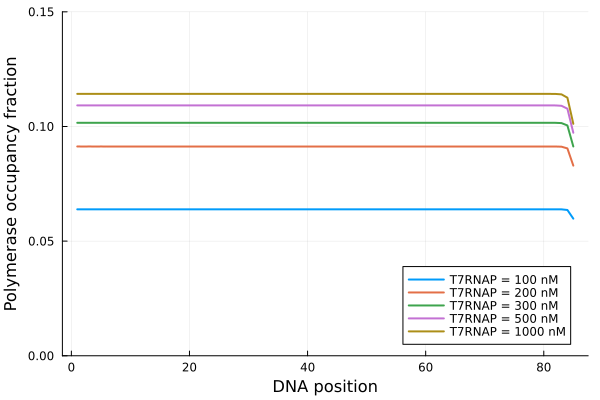

In [3]:
#TASEP models can be used to understand the polymerase density as a function of position on the chain. 
#We find that this density is relatively constant
plt = densitydistributionfinal(basicTASEP, p_base, 10,100, plotlabel = "T7RNAP = 100 nM")
densitydistributionfinal!(plt,basicTASEP, p_base, 10,200, plotlabel = "T7RNAP = 200 nM")
densitydistributionfinal!(plt,basicTASEP, p_base, 10,300, plotlabel = "T7RNAP = 300 nM")
densitydistributionfinal!(plt,basicTASEP, p_base, 10,500, plotlabel = "T7RNAP = 500 nM")
densitydistributionfinal!(plt,basicTASEP, p_base, 10,1000, plotlabel = "T7RNAP = 1000 nM")
plot!(ylims = (0,0.15))
savefig(plt,"./figures/finalhist_low.png")
plt

<h1>Showing that Analytic Approximations are Legitimate in Studied Range<h1>

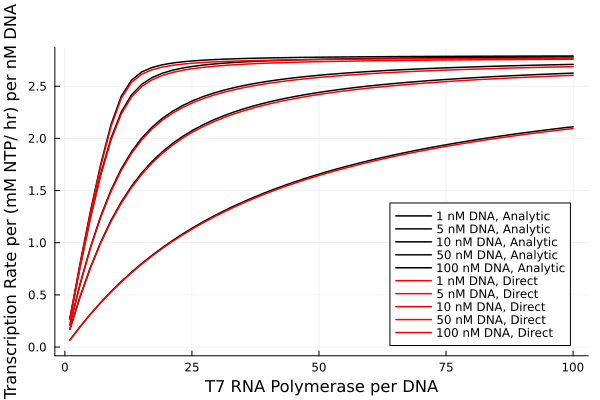

In [4]:
#We can compare the outputs of numerical simulation with our analytic approximation. 
#This is for the SP model
Pmax = 100
Pmin = 1
transcriptionmodel = basicTASEP
npoints = 50
cov = 0
QSkwargs = (showuncertainty = false, thinparameters = false, npoints = npoints, color = :black)
dynamickwargs = (showuncertainty = false, thinparameters = false, npoints = npoints, color = :red, analytic=false)

plt = plotQSrate_constantD(transcriptionmodel, p_composite, cov, p_base, 1, (Pmin,Pmax); modellabel = "1 nM DNA, Analytic", QSkwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_composite, cov, p_base, 5, (Pmin,Pmax); modellabel = "5 nM DNA, Analytic", QSkwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_composite, cov, p_base, 10, (Pmin,Pmax); modellabel = "10 nM DNA, Analytic", QSkwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_composite, cov, p_base, 50, (Pmin,Pmax); modellabel = "50 nM DNA, Analytic", QSkwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_composite, cov, p_base, 100, (Pmin,Pmax); modellabel = "100 nM DNA, Analytic", QSkwargs...)

plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 1, (Pmin,Pmax); modellabel = "1 nM DNA, Direct", dynamickwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 5, (Pmin,Pmax); modellabel = "5 nM DNA, Direct", dynamickwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 10, (Pmin,Pmax); modellabel = "10 nM DNA, Direct", dynamickwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 50, (Pmin,Pmax); modellabel = "50 nM DNA, Direct", dynamickwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 100, (Pmin,Pmax); modellabel = "100 nM DNA, Direct", dynamickwargs...)
plot!(topmargin = 10mm,legend = :bottomright)
savefig(plt,"./figures/comparingapproxbasicTASEPgood.png")
plt

In [5]:
##This does the same thing for the LP TASEP model. I am commenting it out for your safety since it takes a very long time to run.
# Pmax = 100
# Pmin = 1
# transcriptionmodel = longTASEP
# npoints = 100
# cov = 0
# QSkwargs = (showuncertainty = false, thinparameters = false, npoints = npoints, color = :black)
# dynamickwargs = (showuncertainty = false, thinparameters = false, npoints = npoints, color = :red, analytic=false)

# plt = plotQSrate_constantD(transcriptionmodel, p_composite, cov, p_base, 1, (Pmin,Pmax); modellabel = "1 nM DNA, Analytic", QSkwargs...)
# plotQSrate_constantD!(plt, transcriptionmodel, p_composite, cov, p_base, 5, (Pmin,Pmax); modellabel = "5 nM DNA, Analytic", QSkwargs...)
# plotQSrate_constantD!(plt, transcriptionmodel, p_composite, cov, p_base, 10, (Pmin,Pmax); modellabel = "10 nM DNA, Analytic", QSkwargs...)
# plotQSrate_constantD!(plt, transcriptionmodel, p_composite, cov, p_base, 50, (Pmin,Pmax); modellabel = "50 nM DNA, Analytic", QSkwargs...)
# plotQSrate_constantD!(plt, transcriptionmodel, p_composite, cov, p_base, 100, (Pmin,Pmax); modellabel = "100 nM DNA, Analytic", QSkwargs...)

# plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 1, (Pmin,Pmax); modellabel = "1 nM DNA, Direct", dynamickwargs...)
# plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 5, (Pmin,Pmax); modellabel = "5 nM DNA, Direct", dynamickwargs...)
# plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 10, (Pmin,Pmax); modellabel = "10 nM DNA, Direct", dynamickwargs...)
# plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 50, (Pmin,Pmax); modellabel = "50 nM DNA, Direct", dynamickwargs...)
# plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 100, (Pmin,Pmax); modellabel = "100 nM DNA, Direct", dynamickwargs...)
# plot!(topmargin = 10mm,legend = :bottomright)
# savefig(plt,"./figures/comparingapproxlongTASEP.png")
# plt

In [6]:
# fontsize = 30
# pltcompare = plot(plt1,plt,size = (1000,500),bottommargin = 10mm,topmargin = 10mm,leftmargin = 5mm)
# annotate!(sp=1,[(relativex(0.1; sp=1), relativey(0.9; sp=1), text("A",fontsize))])
# annotate!(sp=2,[(relativex(0.1; sp=1), relativey(0.9; sp=1), text("B",fontsize))])
# savefig(pltcompare,"./figures/comparingapproxbasicTASEPgood.png")
# pltcompare

<h1>Comparing Heirachies of Model Complexity<h1>

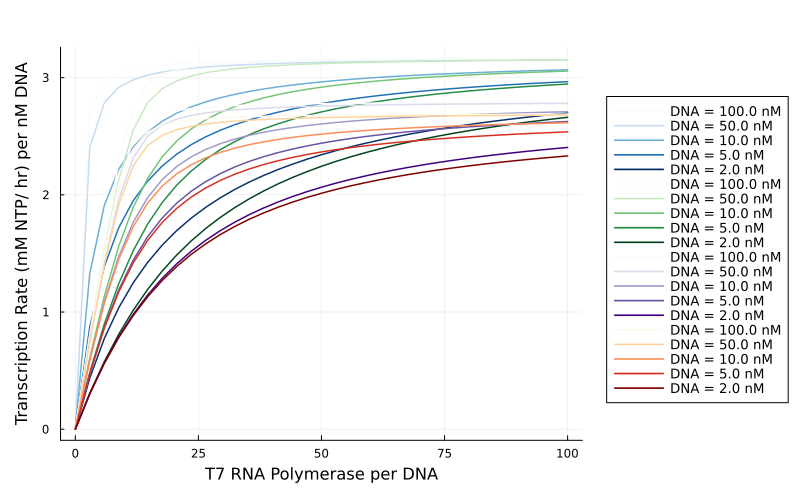

In [7]:
# Given a set of ground truth parameters, we can see how the four models we consider in 
# this work (initiation-limited, initiation-elongation, SP, LP) differ in their kinetic parameters
# The key thing we are getting out of this is that the SP and LP models have the same "shape" as
# the initiation limited model, which implies that we wouldn't be able to differentiate them with macroscopic
# measurements. 
DNApoints = [2,5,5,10,50,100]
Ppoints = [200]
DPinputs = generategridinputs(DNApoints,Ppoints)
heirarchykwargs = (normalizexaxis = true, normalizeyaxis = true, showuncertainty = false, thinparameters = false)


plt = plot(xlabel = "T7 RNA Polymerase per DNA", ylabel = "Transcription Rate per (mM NTP/ hr) per nM DNA")

for (jind,model) in enumerate(modellist)
    plotmodelprediction!(plt,model,p_composite,0,p_base,DPinputs;color =modelcolorlist[jind], modelname= modelnamelist[jind], heirarchykwargs...)
end
plot!(legend = :outerright, size = (800,500),leftmargin = 5mm, bottommargin = 5mm, topmargin = 10mm)
savefig(plt,"./figures/comparingallmodels_normalized.png")
plt

<h1>Practical Identifiability of TASEP Models<h1>

In this section we look at how four models (initiation-limited, initiation-elongation, SP, LP) in this work can fit
synthetic data (generated by themselves or other models).

In [8]:
#Takes two models, generates synthetic data from the first, and fits both models. Shows uncertainty regions of parameters
#of both models
function evaluatemodelfitting(truemodelindex,testmodelindex,noiseval;plotresults = true,uncertaintyparams = true)
    DNApoints = [10,20,50,100]
    Ppoints = [100,200,300,500,800]
    extraDNA = []
    npoints = 1000#Number of multistart points used
    meanK = 50
    stdK = 25
    priorfunc = x->((x[end]-meanK)/stdK)^2
    priormat = [0 0 0 0 0;0 1/stdK^2 0 0 0;0 0 0 0 0;0 0 0 0 0;0 0 0 0 0]
    priormatlist = [priormat[1:2,1:2],priormat[1:3,1:3],priormat[1:4,1:4],priormat]
    ###########You don't have to change anything below this line################
    truemodel = modellist[truemodelindex]
    truemodelname = modelnamelist[truemodelindex]
    testmodel = modellist[testmodelindex]
    testmodelname = modelnamelist[testmodelindex]

    DPinputs = generategridinputs(DNApoints,Ppoints)
    experimentalnoise = noiseval*ones(size(DPinputs)[1])
    experimentaldata = generatesyntheticdata(truemodel,p_composite,DPinputs,experimentalnoise)

    normalizexaxis = false
    normalizeyaxis = false
    
    (p_null,p_thintrue,truecov) = multistartoptimizeparams(truemodel, experimentaldata, DPinputs, experimentalnoise, p_base, npoints = npoints, priorfunc = priorfunc, priormat = priormatlist[truemodelindex])
    (p_estimated,p_thintest,testcov) = multistartoptimizeparams(testmodel, experimentaldata, DPinputs, experimentalnoise, p_base, npoints = npoints, priorfunc = priorfunc, priormat = priormatlist[testmodelindex])
    if plotresults
        plt = plot()
        plotexperimentaldata!(plt,DPinputs,experimentaldata,experimentalnoise,extraDNA = extraDNA)
        plotmodelprediction!(plt,testmodel,p_thintest,testcov,p_base,DPinputs,normalizexaxis = normalizexaxis,normalizeyaxis =normalizeyaxis, modelname = testmodelname, maximumT7 = 800, color =  :Dark2_5, showuncertainty = false, extraDNA = extraDNA)
        plot!(legend = :outertop)
        display(plt)
        pltelps1 = plotparametricellipse(p_thintrue,truecov,title = truemodelname)
        display(pltelps1)
        pltelps2 = plotparametricellipse(p_thintest,testcov,title = testmodelname)
        display(pltelps2)
    end
    if uncertaintyparams
        println("Parameter Estimates (Ground Truth Model)")
        printuncertaintyestimates(p_thintrue,truecov,N_all)
        println("Parameter Estimates (Test Model)")
        printuncertaintyestimates(p_thintest,testcov,N_all)
    end
    return p_estimated
end

evaluatemodelfitting (generic function with 1 method)

got a residual of 12.903170925036617 at [2664.217451177187, 122.2705638697762, 16.633796923459247, 45.67848232595469] (returned FTOL_REACHED)
got a BIC of 37.79
got a residual of 15.042584785011321 at [1358.6352906083505, 34.317878733871524, 10.321247023562035] (returned FTOL_REACHED)
got a BIC of 39.07


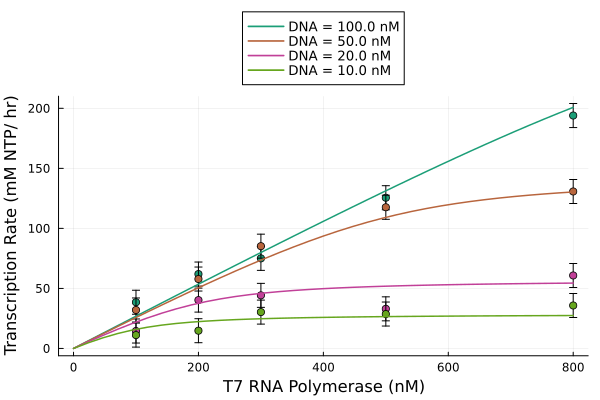

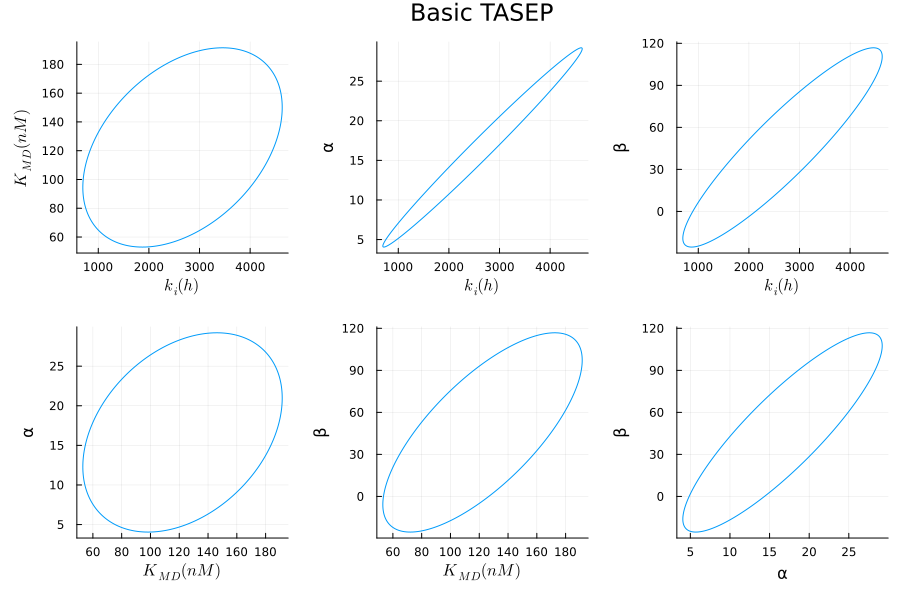

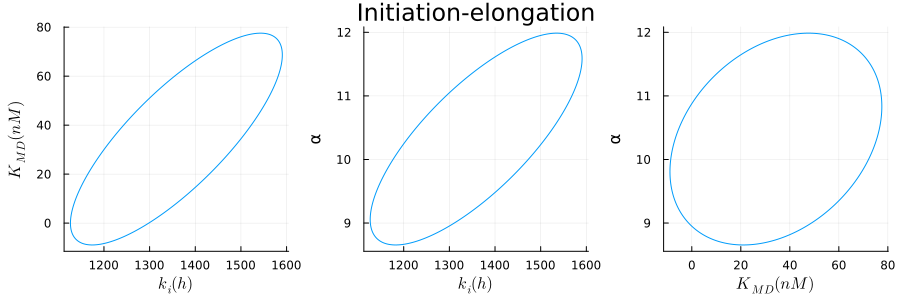

Parameter Estimates (Ground Truth Model)
k_i    K_MD    α    β    k_e,eff  k_e,bp  
2664.2  122.3  16.6  45.7  170.4  360766.4  
1281.3  73.3  7.8  -4.3  157.6  333691.0  
4035.6  170.5  25.4  95.2  197.7  418595.2  
Parameter Estimates (Test Model)
k_i    K_MD    α    k_e,eff  k_e,bp  
1358.6  34.3  10.3  145.8  308567.2  
1196.1  3.8  9.1  133.8  283307.6  
1520.1  64.5  11.5  158.9  336301.8  


ComponentVector{Float64}(k_i = 1358.6352906083505, K = 34.317878733871524, α = 10.321247023562035, β = 0.7313845654681903, θ = 27.542287033381694, N_all = 2117.0)

In [9]:
groundtruthmodelindex = 3 #SP TASEP model
testmodelindex = 2 #initiation-elongation model
noise = 10
evaluatemodelfitting(groundtruthmodelindex,testmodelindex,noise)
#From this we can see that 
# - The initiation-elongation model does a good job fitting data from the SP model
# - The SP model has highly correlated parameter confidence regions

<h1>Distortion of Estimated Parameters of Initiation-Elongation Model<h1>

got a residual of 29.606302717968035 at [1500.0, 35.06009553779078, 11.04181270986469, 0.8915024207593767, 0.0] (returned MAXTIME_REACHED)
got a BIC of 74.19
got a residual of 184163.45295796273 at [1331.2950769441013, 36.191324472324254, 10.261067835867513] (returned FTOL_REACHED)
got a BIC of 368335.89
got a residual of 29.44451150876413 at [1499.5771249456127, 35.06706607321477, 11.038032964582706, 0.8777271575508646, 0.21054597247952037] (returned FTOL_REACHED)
got a BIC of 73.87
got a residual of 800296.6365919465 at [1105.8353700908556, 38.95040522845418, 9.032836571013922] (returned FTOL_REACHED)
got a BIC of 1.60060226e6
got a residual of 14.670862115055535 at [1499.0577036071304, 34.97197554361668, 11.035171842290014, 0.872742188184587, 0.6955140652130735] (returned FTOL_REACHED)
got a BIC of 44.32
got a residual of 1.3558141030013813e6 at [768.0076582373581, 37.39229494156585, 6.781985113526786] (returned FTOL_REACHED)
got a BIC of 2.71163719e6
got a residual of 19.0970534571

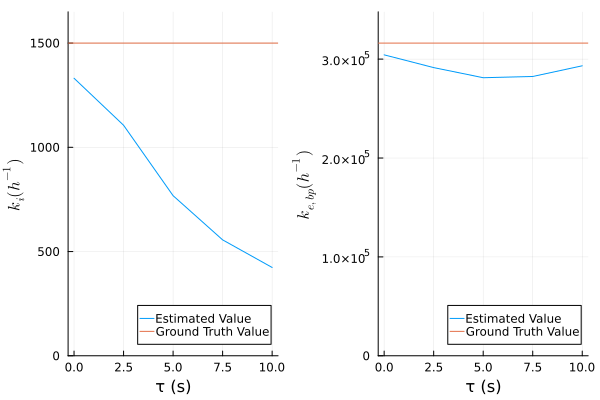

In [10]:
n = 5
m = 3
kineticparams = zeros(2,n)
pausingtime = LinRange(0.00,10,n)

#Basic parameters (from Stover et al, 2023)
k_on = 10^2.30 #P-DNA binding (hours^-1 nM^-1)
k_off = 10^3.74 #P-DNA binding (inverse hours)
k_i = 1500 #Initiation rate (inverse hours)
k_e = 10^5.5 #Elongation rate (inverse hours)
#Basic pausing parameters (Klumpp and Hwa, 2008)
f = 0.1*3600 #Pausing frequency (inverse hours)
#Basic T7 RNA polymerase size parameter (My best guess + Klumpp and Hwa, 2008)
L = 25
#Basic sequence parameter 
N_all = 2117;#Fluc sequence

for i in 1:n
    τ = pausingtime[i]/3600 #Pausing time (hours)
    ##### Composite parameters (see overleaf derivation)

    α = 1+N_all*k_i/k_e     #Dimless
    K = (k_off+k_i)/k_on     #nM
    β = L*k_i^2/(k_e*k_on)   #Dimless
    θ = k_off/k_on;          #nM
    γ = k_i*f*τ^2/(1+f*τ)    #Dimless

    p_initlimited = ComponentVector((k_i = k_i, K = K))
    p_initelongation = ComponentVector((k_i = k_i, K = K, α = α))
    p_basicTASEP = ComponentVector((k_i = k_i, K = K, α = α, β = β))
    p_longTASEP = ComponentVector((k_i = k_i, K = K, α = α, β = β, γ = γ, θ = θ))

    initiationlimited = InitiationLimitedModel()
    initiationelongation = InitiationElongationModel()
    basicTASEP = BasicTASEPModel()
    longTASEP = LPTASEPModel()

    p_base = ComponentVector((k_on = k_on, k_off = k_off, k_i = k_i, k_e = k_e, L = L, f = f, τ = τ, N_all = N_all))
    p_composite = ComponentVector((k_i = k_i, α = α, K = K, γ = γ, β = β, θ = θ, N_all = N_all))

    g = evaluatemodelfitting(4,2,0.01;plotresults = false,uncertaintyparams = false)
    kineticparams[1,i] = g.k_i
    kineticparams[2,i] = N_all*g.k_i/(g.α-1)
end

initplot = plot(pausingtime,kineticparams[1,:],label = "Estimated Value")
hline!([k_i],label = "Ground Truth Value",ylabel = L"k_i (h^{-1})",ylims = (0,k_i*1.1))
elongplot = plot(pausingtime,kineticparams[2,:],label = "Estimated Value")
hline!([k_e],label = "Ground Truth Value",ylabel = L"k_{e,bp} (h^{-1})",ylims = (0,k_e*1.1))
estimationplot = plot(initplot,elongplot,xlabel = "τ (s)")
savefig(estimationplot,"./figures/pubfigs/estimationplot.png")
estimationplot